## Unsupervised ML will be used to classify the lithologies

### 📌 Lithology Clustering: Feature Selection & Standardization

#### ✅ Why These Features Were Chosen for Clustering

To identify lithological zones, we must use features that reflect **formation rock properties**, not operational drilling behavior. The following features were selected:

- **`GR_TMG_interpolated`**  
  - Gamma Ray log indicating natural radioactivity.
  - High GR → Shale; Low GR → Sandstone or carbonate.
  - Primary lithology indicator.

- **`TNPH_interpolated`**  
  - Neutron porosity log.
  - Responds to hydrogen content; useful for distinguishing porous rocks and shales.
  - Strong negative correlation with GR.

- **`DTCO_interpolated`**  
  - Compressional sonic slowness.
  - Reflects rock stiffness and porosity; helps separate shales from sands/carbonates.

**Optional features** (included based on correlation and geological relevance):
- `Hole Diameter (in)` — May indicate borehole enlargement in unstable formations.
- `Differential Pressure (psi)` — Might respond to formation mechanical properties.
- `Surface Stick Slip Index (percent)` — Could highlight problematic formations.

**Excluded features**:  
Drilling parameters (`WOB`, `RPM`, `ROP`, `Torque`, MSE, etc.) were excluded at this stage because they reflect **drilling performance**, not lithology. These will be analyzed *after* clustering.

---

#### 🔄 Why Standardization Is Needed

Clustering algorithms like **KMeans** rely on distance metrics (e.g., Euclidean distance). If features are on different scales (e.g., GR in API vs. DTCO in µs/ft), the larger-scaled features dominate.

- We apply **`StandardScaler`** to:
  - Center each feature (mean = 0)
  - Scale to unit variance (std = 1)
  - Ensure **equal influence** of all features during clustering

---

#### 🧠 Summary

By selecting **formation-driven logs** and standardizing them, we ensure that clustering reveals **geologically meaningful lithology zones**, enabling better MSE optimization per rock type.


In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.utils import resample
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [3]:
df=pd.read_csv("Merged_data.csv")

In [7]:
df.shape

(1059410, 47)

## 1. KMEANs Clustering with PCA Implementation

In [66]:
%%time
X = df.select_dtypes(include='number')  # select numeric columns only
X_scaled = StandardScaler().fit_transform(X)

CPU times: user 388 ms, sys: 763 ms, total: 1.15 s
Wall time: 1.57 s


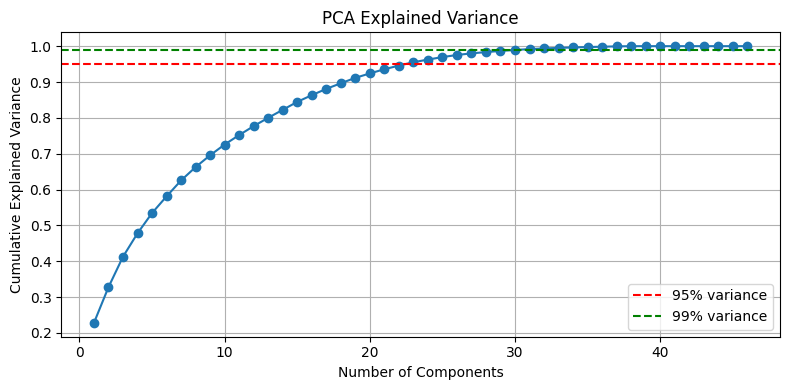

In [53]:
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

cumulative_variance = np.cumsum(pca.explained_variance_ratio_)

exp_var = pca.explained_variance_ratio_

plt.figure(figsize=(8, 4))
plt.plot(range(1, len(cumulative_variance)+1), cumulative_variance, marker='o')
plt.axhline(y=0.95, color='r', linestyle='--', label='95% variance')
plt.axhline(y=0.99, color='g', linestyle='--', label='99% variance')
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA Explained Variance")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


In [54]:
# Find number of components to explain at least 95% variance
n_components_95 = np.argmax(cumulative_variance >= 0.95) + 1
print(f"Number of components to explain 95% variance: {n_components_95}")

Number of components to explain 95% variance: 23


In [55]:
pca_final = PCA(n_components=n_components_95)
X_pca_final = pca_final.fit_transform(X_scaled)

In [56]:
X_pca_final.shape

(1059410, 23)

In [57]:
X_pca_sample = resample(X_pca_final, n_samples=100_000, random_state=42)

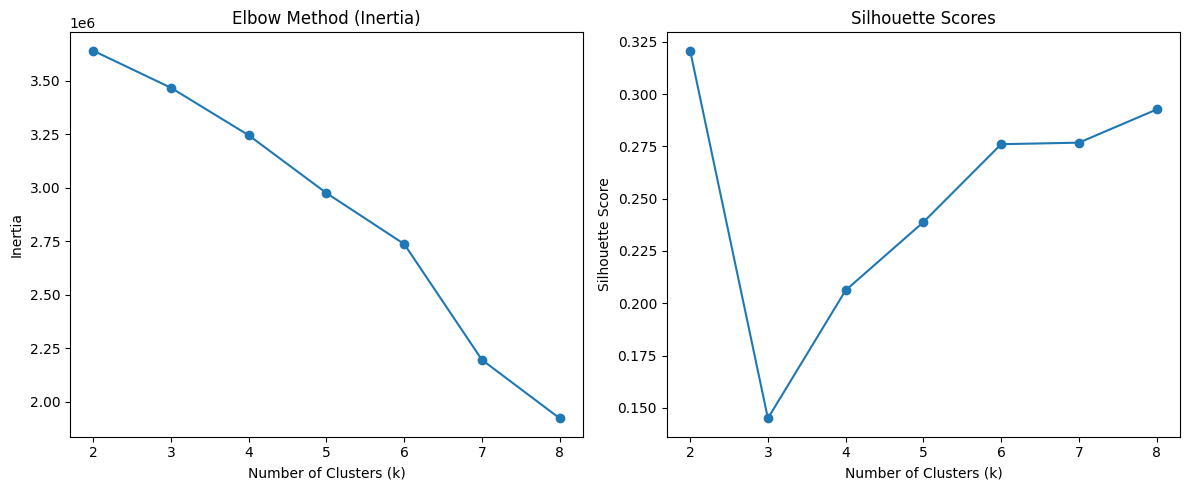

CPU times: user 5min, sys: 40.4 s, total: 5min 40s
Wall time: 5min 36s


In [58]:
%%time
# Try different values of k to find the "elbow"
inertia = []
silhouette_scores = []
k_values = range(2, 9)

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_pca_sample)
    inertia.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_pca_sample, kmeans.labels_))

# Plot inertia and silhouette score side-by-side
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

ax[0].plot(k_values, inertia, marker='o')
ax[0].set_title("Elbow Method (Inertia)")
ax[0].set_xlabel("Number of Clusters (k)")
ax[0].set_ylabel("Inertia")

ax[1].plot(k_values, silhouette_scores, marker='o')
ax[1].set_title("Silhouette Scores")
ax[1].set_xlabel("Number of Clusters (k)")
ax[1].set_ylabel("Silhouette Score")

plt.tight_layout()
plt.show()


## 2. KMEANS Clustering with Important Features

In [67]:
# Step 1: Define core and optional features based on correlation insights
core_features = [
    'GR_TMG_interpolated',
    'TNPH_interpolated',
    'DTCO_interpolated'
]

optional_features = [
    'Hole Diameter (in)',          # Include if reflects formation response
    'Differential Pressure (psi)', # Optional – weakly correlated but may help
    'Surface Stick Slip Index (percent)'  # Optional stick-slip metric
]

# Combine selected features
selected_features = core_features + optional_features

# Step 2: Filter relevant columns from df.
df_cluster_input = df[selected_features].copy()

# Step 3: Remove columns that are all NaN or constant
df_cluster_input = df_cluster_input.dropna(axis=1, how='all')  # Drop all-NaN columns
df_cluster_input = df_cluster_input.loc[:, df_cluster_input.nunique() > 1]  # Drop constant columns

# Step 4: Drop rows with NaNs in any selected feature (clean rows only)
df_cluster_input_clean = df_cluster_input.dropna()

# Step 5: Standardize for clustering (mean=0, std=1)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_cluster_input_clean)

# Now X_scaled is ready for clustering
print("✅ Data is ready for clustering.")
print("Input shape:", X_scaled.shape)
print("Used features:", df_cluster_input_clean.columns.tolist())


✅ Data is ready for clustering.
Input shape: (1059410, 6)
Used features: ['GR_TMG_interpolated', 'TNPH_interpolated', 'DTCO_interpolated', 'Hole Diameter (in)', 'Differential Pressure (psi)', 'Surface Stick Slip Index (percent)']


In [62]:
X_sampled = resample(X_scaled, n_samples=100_000, random_state=42)

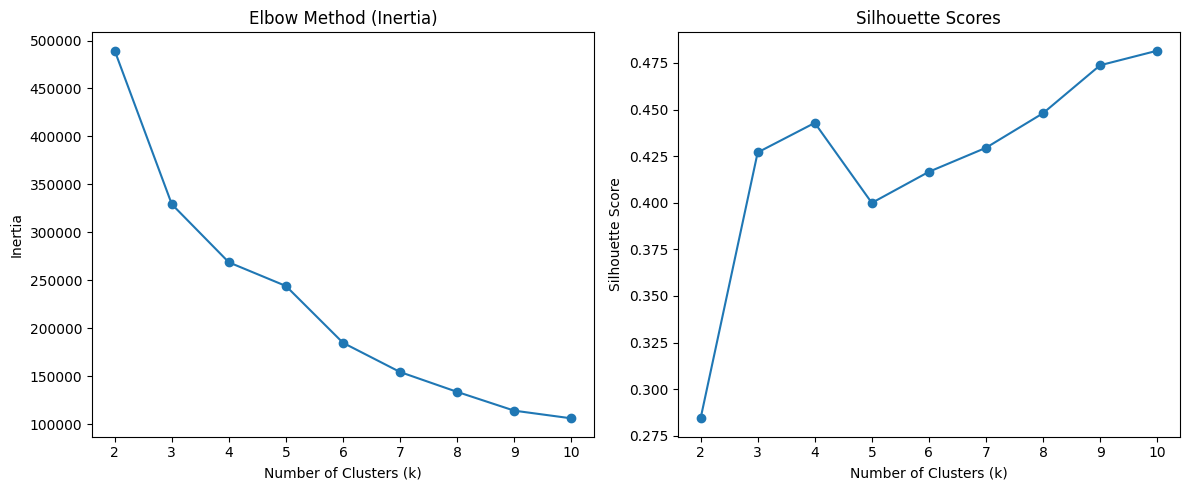

CPU times: user 10min 15s, sys: 1min 27s, total: 11min 42s
Wall time: 11min 41s


In [63]:
%%time
# Try different values of k to find the "elbow"
inertia = []
silhouette_scores = []
k_values = range(2, 11)

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_sampled)
    inertia.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_sampled, kmeans.labels_))

# Plot inertia and silhouette score side-by-side
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

ax[0].plot(k_values, inertia, marker='o')
ax[0].set_title("Elbow Method (Inertia)")
ax[0].set_xlabel("Number of Clusters (k)")
ax[0].set_ylabel("Inertia")

ax[1].plot(k_values, silhouette_scores, marker='o')
ax[1].set_title("Silhouette Scores")
ax[1].set_xlabel("Number of Clusters (k)")
ax[1].set_ylabel("Silhouette Score")

plt.tight_layout()
plt.show()

In [50]:
for idx, i in enumerate(silhouette_scores):
    print(f"k value: {idx+2} silhouette_scores: {i}")

k value: 2 silhouette_scores: 0.28434658154432624
k value: 3 silhouette_scores: 0.42697431046547946
k value: 4 silhouette_scores: 0.4428210172613532
k value: 5 silhouette_scores: 0.399911340942075
k value: 6 silhouette_scores: 0.4165888477751932
k value: 7 silhouette_scores: 0.4294674059072635
k value: 8 silhouette_scores: 0.4480040760886152


In [51]:
for idx, i in enumerate(inertia):
    print(f"k value: {idx+2} inertia: {i}")

k value: 2 inertia: 489370.94249133975
k value: 3 inertia: 329299.6834565164
k value: 4 inertia: 268708.1506407233
k value: 5 inertia: 244045.84828339127
k value: 6 inertia: 184810.5576391502
k value: 7 inertia: 154350.1094595741
k value: 8 inertia: 133651.12529996323


In [64]:
for idx, i in enumerate(silhouette_scores):
    print(f"k value: {idx+2} silhouette_scores: {i}")

k value: 2 silhouette_scores: 0.28434658154432624
k value: 3 silhouette_scores: 0.42697431046547946
k value: 4 silhouette_scores: 0.4428210172613532
k value: 5 silhouette_scores: 0.399911340942075
k value: 6 silhouette_scores: 0.4165888477751932
k value: 7 silhouette_scores: 0.4294674059072635
k value: 8 silhouette_scores: 0.4480040760886152
k value: 9 silhouette_scores: 0.47373079260281115
k value: 10 silhouette_scores: 0.48153756283197086


In [65]:
for idx, i in enumerate(inertia):
    print(f"k value: {idx+2} inertia: {i}")

k value: 2 inertia: 489370.94249133975
k value: 3 inertia: 329299.6834565164
k value: 4 inertia: 268708.1506407233
k value: 5 inertia: 244045.84828339127
k value: 6 inertia: 184810.5576391502
k value: 7 inertia: 154350.1094595741
k value: 8 inertia: 133651.12529996323
k value: 9 inertia: 114076.73821344972
k value: 10 inertia: 106064.66996812155


## Selected Model: Method 2

In [72]:
%%time
# Step 1: Fit KMeans on all data
kmeans_final = KMeans(n_clusters=3, random_state=42, n_init=10)
cluster_labels_full = kmeans_final.fit_predict(X_scaled)

# Step 2: Assign cluster labels to your drilling DataFrame
df['LithoCluster_KMeans_3'] = cluster_labels_full

CPU times: user 5.9 s, sys: 2.45 s, total: 8.35 s
Wall time: 1.5 s


In [73]:
# Step 3: Save model to file
with open("kmeans_k3_full_model.pkl", "wb") as f:
    pickle.dump(kmeans_final, f)

# Step 4: (Optional) Save labels if you want to reload later
import numpy as np
np.save("cluster_labels_k3.npy", cluster_labels_full)

print("✅ KMeans clustering with k=3 completed and saved.")


✅ KMeans clustering with k=3 completed and saved.


In [75]:
# Example: Based on your visual or statistical interpretation
cluster_to_lithology = {
    0: 'Alluvium',
    1: 'Transition Zone',
    2: 'Granodiorite'
}

df['Lithology_Class_KMeans'] = df['LithoCluster_KMeans_3'].map(cluster_to_lithology)


In [76]:
df.head()

,Unnamed: 0,Time,Hole Depth (feet),Bit Depth (feet),ROP,WOB,Hook Load,Rotary RPM (RPM),Standpipe Pressure (psi),Rotary Torque (kft_lb),Differential Pressure (psi),Flow (flow_percent),Total Pump Output (gal_per_min),Pason Gas (percent),AutoDriller Torque (kft_lb),AutoDriller WOB (klbs),Azimuth (degrees),Bit RPM (RPM),Bit Torque (kft_lb),DAS BHA Stick Slip (unitless),DAS Bit Stick Slip (unitless),DAS Downhole MSE (ksi),DAS MSE (ksi),DAS Recommended DIFFP (psi),DAS Recommended ROP (ft_per_hr),DAS Recommended RPM (RPM),DAS Recommended WOB (klbs),DAS ROP (ft_per_hr),Depth of Cut (in),dexponent (log),EDR Instantaneous ROP (ft_per_hr),Hole Diameter (in),Inclination (degrees),Mechanical Specific Energy (ksi),MWD Temp (Fahrenheit),On Bottom (unitless),On Bottom ROP (ft_per_hr),Relative MSE (unitless),Surface Stick Slip Index (percent),Temp IN (Degrees),Temp OUT (Degrees),Top Drive Rotary (RPM),Top Drive Torque (kft_lb),TTS Mechanical Specific Energy (ksi),GR_TMG_interpolated,DTCO_interpolated,TNPH_interpolated,LithoCluster_KMeans_3,Lithology_Class_KMeans
0,244721,2021-02-11 00:44:22,3454.0,3454.0,77.26,33.4,112.7,101.07,3177.14,9.978,305.80,98.63,820.75,0.0,10.187,33.84,0.0,232.0,0.0,0.040,0.017,0.110,14.002,0.0,0.0,0.0,0.0,77.740,0.067,1.26,77.263,12.5,0.0,0.3,0.0,1.0,77.26,638.0,5.0,87.20,141.88,101.0,10.187,0.0,84.79170,52.72340,0.1558,0,Alluvium
1,244722,2021-02-11 00:44:23,3454.0,3454.0,76.70,33.6,111.8,101.23,3183.11,10.155,311.78,98.62,814.83,0.0,9.987,33.34,0.0,232.0,0.0,0.040,0.017,0.110,14.002,0.0,0.0,0.0,0.0,77.740,0.066,1.27,76.699,12.5,0.0,0.3,0.0,1.0,76.70,652.0,5.0,87.02,141.88,101.0,9.987,0.0,84.79170,52.72340,0.1558,0,Alluvium
2,244723,2021-02-11 00:44:24,3454.0,3454.0,76.41,33.6,111.9,101.29,3183.87,9.786,312.54,98.55,817.77,0.0,9.782,34.04,0.0,232.0,0.0,0.040,0.017,0.110,14.002,0.0,0.0,0.0,0.0,77.740,0.066,1.27,76.429,12.5,0.0,0.3,0.0,1.0,76.41,630.0,5.0,86.83,141.88,101.0,9.782,0.0,84.79170,52.72340,0.1558,0,Alluvium
3,244724,2021-02-11 00:44:25,3454.0,3454.0,76.36,33.2,112.1,101.07,3183.84,9.847,312.50,98.60,820.75,0.0,9.838,33.04,0.0,232.0,0.0,0.040,0.017,0.110,14.002,0.0,0.0,0.0,0.0,77.740,0.066,1.27,76.328,12.5,0.0,0.3,0.0,1.0,76.36,636.0,5.0,86.72,141.88,101.0,9.838,0.0,84.79170,52.72340,0.1558,0,Alluvium
4,244725,2021-02-11 00:44:26,3454.1,3454.1,76.21,33.2,112.4,101.07,3180.26,10.211,308.92,98.63,822.73,0.0,10.319,33.56,0.0,233.0,0.0,0.062,0.027,0.109,13.943,0.0,0.0,0.0,0.0,78.004,0.066,1.27,76.076,12.5,0.0,0.3,0.0,1.0,76.21,663.0,4.5,86.66,141.88,101.0,10.319,0.0,81.88028,52.87878,0.1611,0,Alluvium


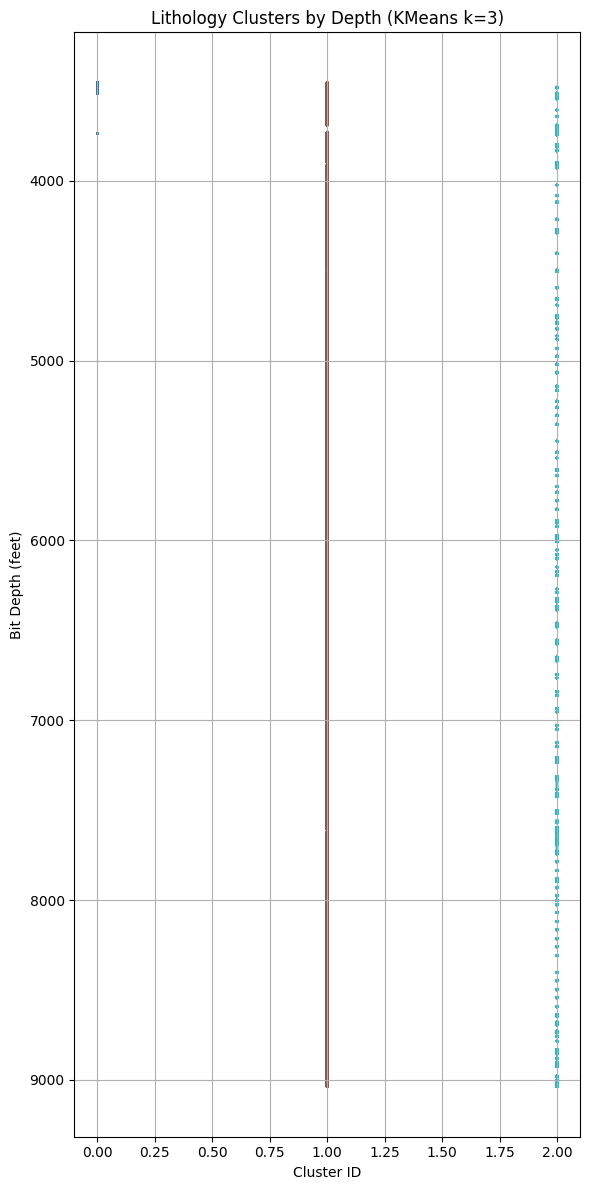

In [78]:
plt.figure(figsize=(6, 12))

plt.scatter(
    df['LithoCluster_KMeans_3'],
    df['Hole Depth (feet)'],
    c=df['LithoCluster_KMeans_3'],
    cmap='tab10', s=1
)

plt.gca().invert_yaxis()  # Depth increases downward
plt.xlabel("Cluster ID")
plt.ylabel("Bit Depth (feet)")
plt.title("Lithology Clusters by Depth (KMeans k=3)")
plt.grid(True)
plt.tight_layout()
plt.show()


## Questions

1. Why number of column reduced by 1 after implementing StandardScaler?
2. Why added 1 here: n_components_95 = np.argmax(cumulative_variance >= 0.95) + 1